In [27]:
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

In [46]:
DATA_DIR = Path('../data/2nd_test')
files = sorted([f for f in DATA_DIR.iterdir() if f.is_file() and not f.name.startswith('.')])

In [ ]:
cols = ['B1', 'B2', 'B3', 'B4']

def read_single(file):
    df = pd.read_csv(file, sep='\t', header=None, names=cols)
    return df

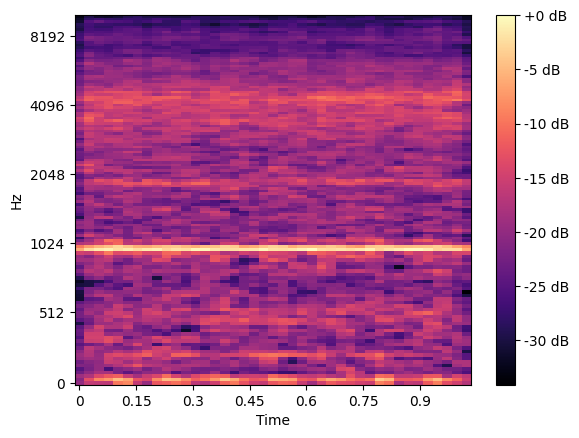

In [52]:
healthy = read_single(files[1])
healthy_B1 = np.array(healthy["B1"].values)

# Create mel spectrogram from the given signal
def create_spectrogram(signal):
    mel_spec = librosa.feature.melspectrogram(y = signal, sr = 20000, n_fft=2048, n_mels=128)
    mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec

librosa.display.specshow(create_spectrogram(healthy_B1), sr = 20000,  x_axis='time', y_axis = 'mel')
plt.colorbar(format='%+2.0f dB')

In [ ]:
from tqdm import tqdm

dataset = []

for file in tqdm(files):
    df = read_single(file)
    signal = df['B1'].values

    mel_spectrogram = create_spectrogram(signal)
    
    dataset.append(mel_spectrogram)

spectograms_dataset = np.array(dataset)

#CNNs require a 4D array that includes the color, we will be using a 1 to indicate our Greyscale
spectograms_dataset = np.expand_dims(spectograms_dataset, axis=-1)
print(spectograms_dataset.shape)

100%|██████████| 984/984 [00:12<00:00, 75.78it/s]

(984, 128, 41, 1)


In [ ]:
# Save dataset
np.save('spectograms.npy', spectograms_dataset)